# Solar Power Generation Analysis

Notebook này trình bày quy trình phân tích dữ liệu cho bài toán dự đoán sản lượng điện mặt trời của hai nhà máy. Toàn bộ pipeline được xây dựng theo đúng các bước thường dùng trong một bài toán data engineering và data mining: đọc dữ liệu, kiểm tra chất lượng dữ liệu, khai phá dữ liệu riêng theo từng nhóm bảng, ghép dữ liệu, tạo đặc trưng, huấn luyện mô hình dự đoán, đánh giá kết quả và trực quan hóa.

Bộ dữ liệu gồm hai nhóm bảng:
- `Generation Data`: dữ liệu phát điện theo từng inverter và từng mốc thời gian.
- `Weather Sensor Data`: dữ liệu thời tiết ghi nhận theo thời gian tại mỗi nhà máy.

Mục tiêu chính của notebook:
- Hiểu cấu trúc và chất lượng dữ liệu của cả hai nhà máy.
- Khai phá riêng dữ liệu phát điện và dữ liệu thời tiết.
- Ghép bảng `generation` với `weather sensor` theo thời gian.
- Dự đoán `AC_POWER_TOTAL` ở mức nhà máy.
- Đánh giá mô hình bằng các chỉ số hồi quy.
- Trực quan hóa các kết quả để dễ diễn giải trong báo cáo.

## Tổng quan phương pháp

Ý tưởng xử lý dữ liệu trong notebook này là tổng hợp dữ liệu phát điện từ mức inverter lên mức nhà máy theo từng `DATE_TIME`, sau đó ghép với dữ liệu thời tiết tại cùng thời điểm. Đây là cách hợp lý vì bảng thời tiết chỉ có một cảm biến cho mỗi nhà máy, còn bảng phát điện có nhiều inverter hoạt động song song.

Sau khi ghép dữ liệu, ta tạo thêm các đặc trưng thời gian như giờ, phút, ngày trong tuần, ngày trong năm và các biến tuần hoàn để giúp mô hình học tốt chu kỳ ngày đêm. Mô hình được chọn là `RandomForestRegressor` vì bài toán này có quan hệ phi tuyến tương đối rõ giữa bức xạ, nhiệt độ và sản lượng điện.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Đọc dữ liệu và chuẩn bị đường dẫn

Cell dưới đây thiết lập thư mục làm việc, thư mục dữ liệu đầu vào và thư mục lưu kết quả đầu ra. Ngoài ra, ta định nghĩa hàm `resolve_dataset_path()` để notebook có thể đọc dữ liệu linh hoạt dù file nằm trực tiếp ở thư mục gốc hay trong thư mục `datasets`.

Hàm `load_plant_data()` chịu trách nhiệm đọc dữ liệu cho từng nhà máy, chuẩn hóa cột `DATE_TIME` và thêm biến `PLANT_NO`. Đây là bước quan trọng vì định dạng thời gian ở Plant 1 khác Plant 2, nếu không xử lý từ đầu thì rất dễ ghép sai dữ liệu.

In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'datasets'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

def resolve_dataset_path(filename: str) -> Path:
    candidate = DATA_DIR / filename
    if candidate.exists():
        return candidate
    candidate = BASE_DIR / filename
    if candidate.exists():
        return candidate
    raise FileNotFoundError(filename)

def load_plant_data(plant_no: int):
    gen = pd.read_csv(resolve_dataset_path(f'Plant_{plant_no}_Generation_Data.csv'))
    weather = pd.read_csv(resolve_dataset_path(f'Plant_{plant_no}_Weather_Sensor_Data.csv'))

    if plant_no == 1:
        gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'], format='%d-%m-%Y %H:%M', errors='coerce')
    else:
        gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'], errors='coerce')

    weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'], errors='coerce')

    gen['PLANT_NO'] = plant_no
    weather['PLANT_NO'] = plant_no

    return (
        gen.sort_values(['DATE_TIME', 'SOURCE_KEY']).reset_index(drop=True),
        weather.sort_values('DATE_TIME').reset_index(drop=True)
    )

plant_1_gen, plant_1_weather = load_plant_data(1)
plant_2_gen, plant_2_weather = load_plant_data(2)

print('Plant 1 generation:', plant_1_gen.shape)
print('Plant 1 weather   :', plant_1_weather.shape)
print('Plant 2 generation:', plant_2_gen.shape)
print('Plant 2 weather   :', plant_2_weather.shape)

Plant 1 generation: (68778, 8)
Plant 1 weather   : (3182, 7)
Plant 2 generation: (67698, 8)
Plant 2 weather   : (3259, 7)


## 2. Khám phá dữ liệu ban đầu

Trước khi đi sâu vào mô hình, ta cần xem dữ liệu mẫu để hiểu ý nghĩa từng cột. Ở bảng `generation`, mỗi dòng tương ứng với một inverter tại một thời điểm. Ở bảng `weather`, mỗi dòng là một bản ghi thời tiết của nhà máy tại cùng mốc thời gian.

Mục tiêu của bước này:
- Kiểm tra nhanh nội dung của các cột.
- Nhận diện đơn vị quan sát của từng bảng.
- Đảm bảo dữ liệu thời gian đã được parse đúng.
- Làm rõ tại sao phải tổng hợp dữ liệu `generation` trước khi ghép.

In [3]:
plant_1_gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_NO
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0000,0.0000,0.0000,"6,259,559.0000",1
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0000,0.0000,0.0000,"6,183,645.0000",1
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0000,0.0000,0.0000,"6,987,759.0000",1
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0000,0.0000,0.0000,"7,602,960.0000",1
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0000,0.0000,0.0000,"7,158,964.0000",1


In [4]:
plant_1_weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT_NO
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.1843,22.8575,0.0000,1
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.0846,22.7617,0.0000,1
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.9358,22.5923,0.0000,1
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.8461,22.3609,0.0000,1
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.6215,22.1654,0.0000,1


Cell tiếp theo kiểm tra kích thước bảng, kiểu dữ liệu, số lượng giá trị thiếu, số dòng trùng và số lượng `SOURCE_KEY`. Đây là những thông tin cơ bản nhưng rất quan trọng trong bất kỳ bài toán tiền xử lý dữ liệu nào.

Nếu phát hiện thiếu dữ liệu hoặc trùng lặp lớn ở bước này, ta phải xử lý trước khi phân tích sâu hơn. Trong bài toán này, kết quả kiểm tra giúp xác nhận dữ liệu tương đối sạch và có thể dùng để xây dựng pipeline tiếp theo.

In [5]:
def inspect_dataframe(name: str, df: pd.DataFrame):
    print(f'===== {name} =====')
    print('Shape:')
    print(df.shape)
    print('\nDtypes:')
    print(df.dtypes)
    print('\nMissing values:')
    print(df.isna().sum())
    print('\nDuplicate rows:', df.duplicated().sum())
    print('\nUnique SOURCE_KEY:', df['SOURCE_KEY'].nunique())
    print('\nTime range:')
    print(df['DATE_TIME'].min(), '->', df['DATE_TIME'].max())
    print()

inspect_dataframe('Plant 1 Generation', plant_1_gen)
inspect_dataframe('Plant 1 Weather', plant_1_weather)
inspect_dataframe('Plant 2 Generation', plant_2_gen)
inspect_dataframe('Plant 2 Weather', plant_2_weather)

===== Plant 1 Generation =====
Shape:
(68778, 8)

Dtypes:
DATE_TIME      datetime64[ns]
PLANT_ID                int64
SOURCE_KEY             object
DC_POWER              float64
AC_POWER              float64
DAILY_YIELD           float64
TOTAL_YIELD           float64
PLANT_NO                int64
dtype: object

Missing values:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
PLANT_NO       0
dtype: int64

Duplicate rows: 0

Unique SOURCE_KEY: 22

Time range:
2020-05-15 00:00:00 -> 2020-06-17 23:45:00

===== Plant 1 Weather =====
Shape:
(3182, 7)

Dtypes:
DATE_TIME              datetime64[ns]
PLANT_ID                        int64
SOURCE_KEY                     object
AMBIENT_TEMPERATURE           float64
MODULE_TEMPERATURE            float64
IRRADIATION                   float64
PLANT_NO                        int64
dtype: object

Missing values:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY            

## 3. Khai phá riêng dữ liệu generation

Bảng `generation` cho biết cách từng nhà máy phát điện qua thời gian. Vì dữ liệu đang ở mức inverter, các thống kê ở đây giúp ta hiểu quy mô vận hành tổng thể của từng nhà máy.

Các chỉ số được tính gồm:
- Số lượng bản ghi.
- Số mốc thời gian duy nhất.
- Số inverter hoạt động.
- Công suất AC và DC trung bình.
- Tổng `DAILY_YIELD`.
- Tỷ lệ thời điểm có `AC_POWER = 0`.

Tỷ lệ `AC_POWER = 0` đặc biệt hữu ích vì nó phản ánh các khoảng thời gian không phát điện, thường xảy ra vào ban đêm hoặc trong các tình huống nhà máy không hoạt động bình thường.

In [6]:
def generation_summary(gen: pd.DataFrame, plant_no: int) -> pd.DataFrame:
    return pd.DataFrame({
        'plant_no': [plant_no],
        'rows': [len(gen)],
        'timestamps': [gen['DATE_TIME'].nunique()],
        'source_keys': [gen['SOURCE_KEY'].nunique()],
        'ac_power_mean': [gen['AC_POWER'].mean()],
        'dc_power_mean': [gen['DC_POWER'].mean()],
        'daily_yield_sum': [gen['DAILY_YIELD'].sum()],
        'zero_ac_ratio': [(gen['AC_POWER'] == 0).mean()]
    })

pd.concat([
    generation_summary(plant_1_gen, 1),
    generation_summary(plant_2_gen, 2)
], ignore_index=True)

,plant_no,rows,timestamps,source_keys,ac_power_mean,dc_power_mean,daily_yield_sum,zero_ac_ratio
0,1,68778,3158,22,307.8028,"3,147.4262","226,690,137.8059",0.4646
1,2,67698,3259,22,241.2778,246.7020,"223,057,483.2031",0.5268


Biểu đồ theo ngày giúp nhìn ra quy luật vận hành rõ hơn so với việc chỉ xem từng dòng dữ liệu theo 15 phút. Ta tổng hợp `AC_POWER`, `DC_POWER` và `DAILY_YIELD` theo ngày để trả lời các câu hỏi:
- Ngày nào sản lượng điện đạt đỉnh.
- Có khoảng thời gian nào nhà máy suy giảm công suất bất thường không.
- Hai nhà máy có xu hướng vận hành giống nhau hay khác nhau.

Khi đọc biểu đồ, nên chú ý các ngày sụt giảm đồng loạt vì đó có thể là do thời tiết xấu. Nếu chỉ một nhà máy giảm mạnh còn nhà máy kia không giảm tương ứng, đó có thể là dấu hiệu vận hành hoặc thiết bị.

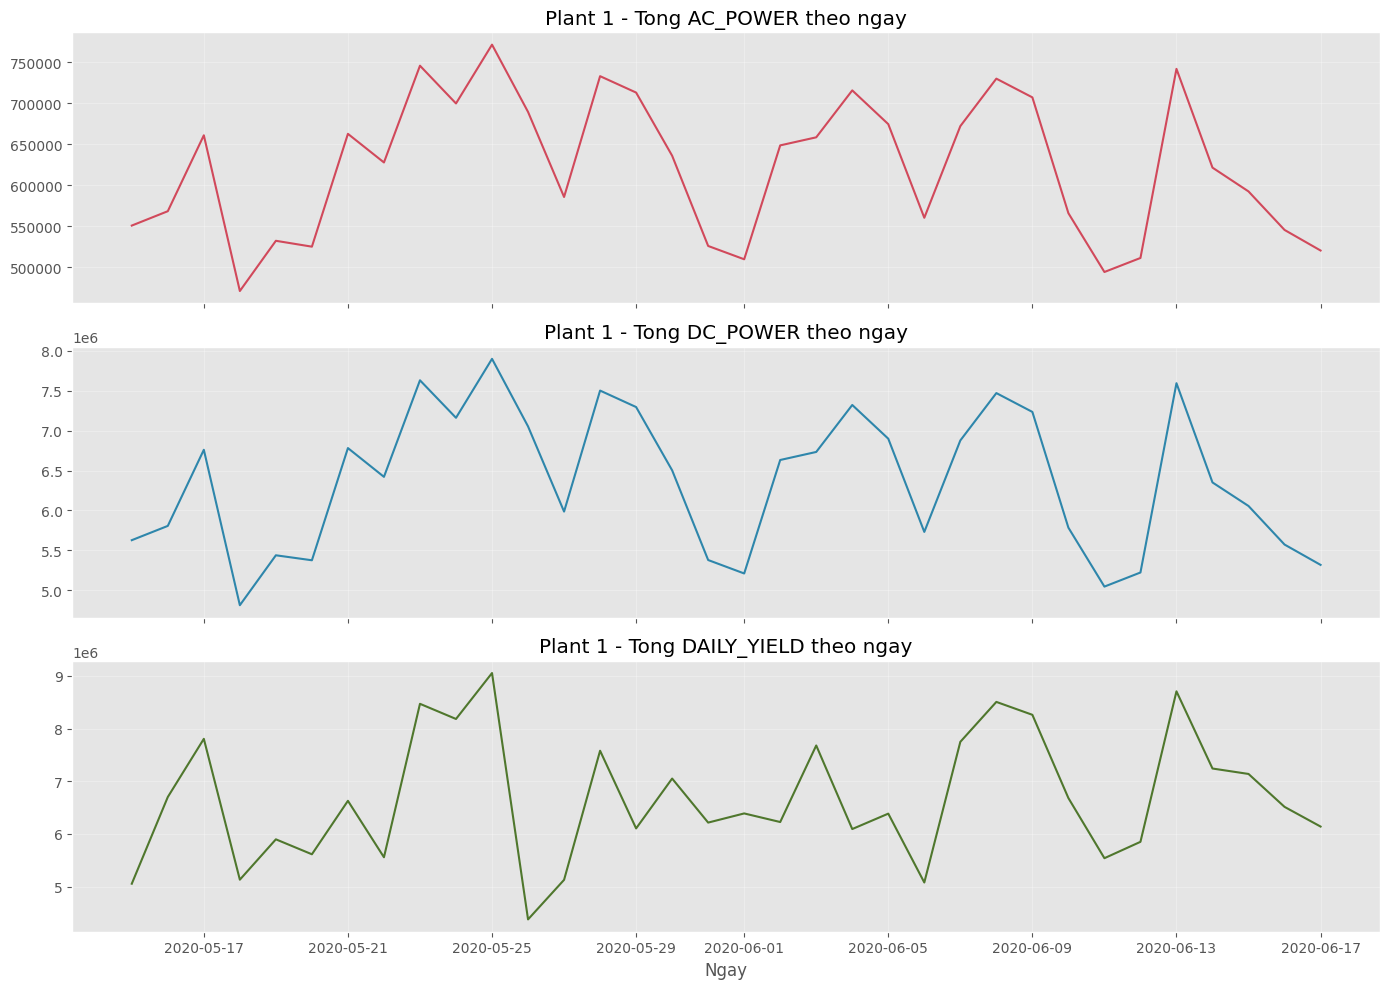

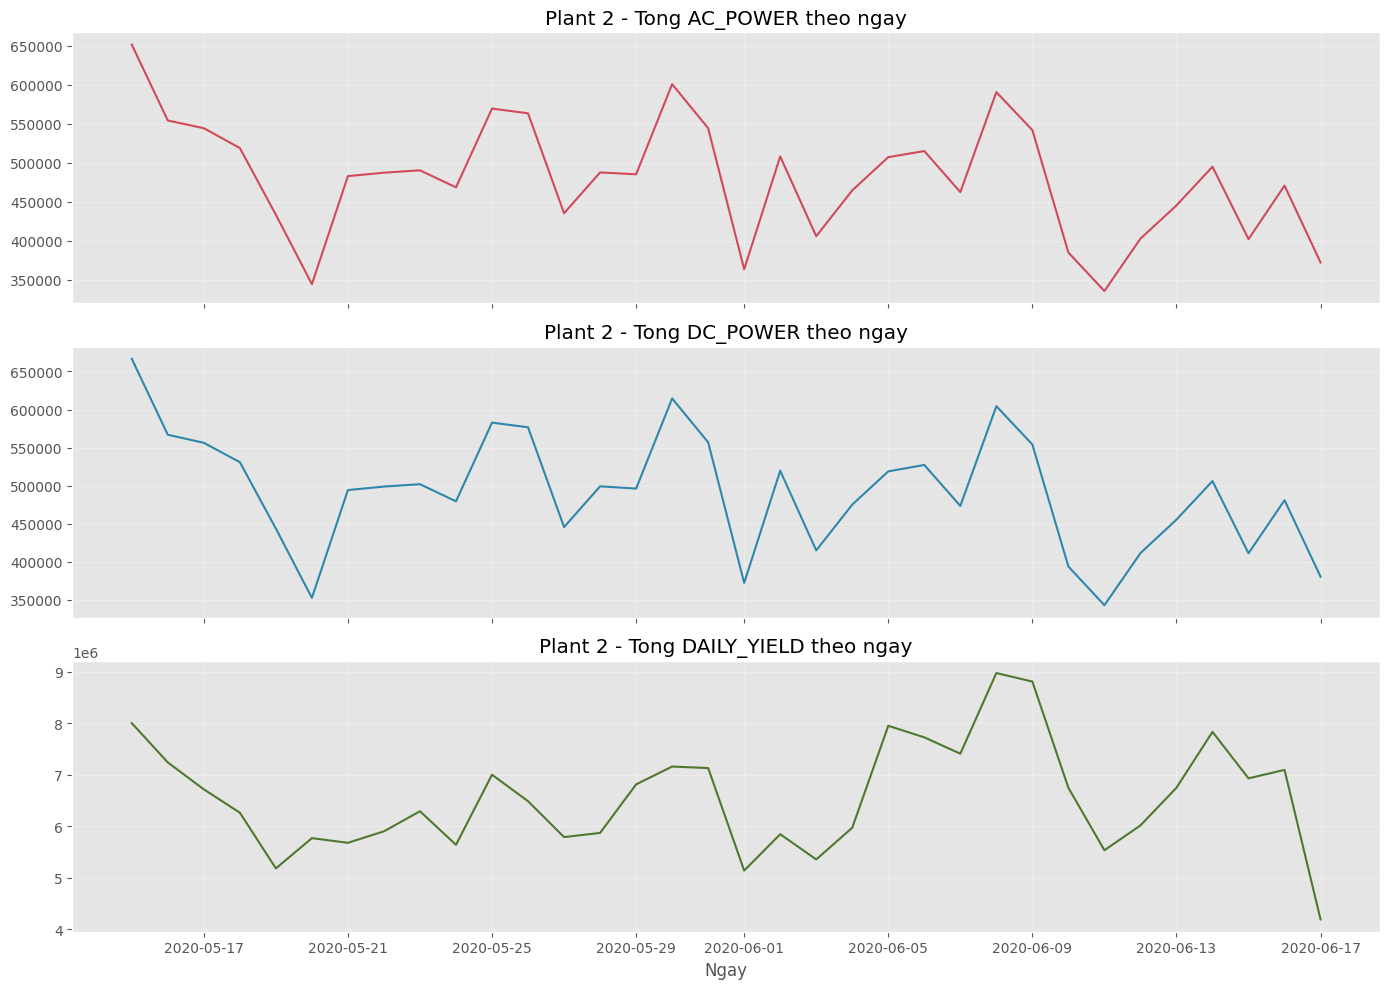

In [7]:
def plot_daily_generation(gen: pd.DataFrame, plant_no: int):
    daily = gen.copy()
    daily['DATE'] = daily['DATE_TIME'].dt.floor('D')
    daily = daily.groupby('DATE', as_index=False)[['AC_POWER', 'DC_POWER', 'DAILY_YIELD']].sum()

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(daily['DATE'], daily['AC_POWER'], color='#d1495b')
    axes[0].set_title(f'Plant {plant_no} - Tong AC_POWER theo ngay')

    axes[1].plot(daily['DATE'], daily['DC_POWER'], color='#2e86ab')
    axes[1].set_title(f'Plant {plant_no} - Tong DC_POWER theo ngay')

    axes[2].plot(daily['DATE'], daily['DAILY_YIELD'], color='#4f772d')
    axes[2].set_title(f'Plant {plant_no} - Tong DAILY_YIELD theo ngay')
    axes[2].set_xlabel('Ngay')

    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_daily_generation(plant_1_gen, 1)
plot_daily_generation(plant_2_gen, 2)

## 4. Khai phá riêng dữ liệu weather sensor

Dữ liệu thời tiết giải thích trực tiếp tại sao công suất phát điện thay đổi. Trong điện mặt trời, biến có ý nghĩa vật lý mạnh nhất thường là `IRRADIATION`, vì nó phản ánh mức bức xạ mặt trời mà hệ thống nhận được. Nhiệt độ môi trường và nhiệt độ tấm pin cũng có ảnh hưởng nhưng quan hệ thường phức tạp hơn.

Bước này giúp ta:
- So sánh điều kiện thời tiết giữa hai nhà máy.
- Quan sát biến động của bức xạ và nhiệt độ theo ngày.
- Kiểm tra xem dữ liệu cảm biến có tuân theo quy luật thực tế hay không.

In [8]:
def weather_summary(weather: pd.DataFrame, plant_no: int) -> pd.DataFrame:
    return pd.DataFrame({
        'plant_no': [plant_no],
        'rows': [len(weather)],
        'timestamps': [weather['DATE_TIME'].nunique()],
        'ambient_temperature_mean': [weather['AMBIENT_TEMPERATURE'].mean()],
        'module_temperature_mean': [weather['MODULE_TEMPERATURE'].mean()],
        'irradiation_mean': [weather['IRRADIATION'].mean()],
        'irradiation_max': [weather['IRRADIATION'].max()]
    })

pd.concat([
    weather_summary(plant_1_weather, 1),
    weather_summary(plant_2_weather, 2)
], ignore_index=True)

,plant_no,rows,timestamps,ambient_temperature_mean,module_temperature_mean,irradiation_mean,irradiation_max
0,1,3182,3182,25.5316,31.0910,0.2283,1.2217
1,2,3259,3259,28.0694,32.7724,0.2327,1.0988


Các biểu đồ thời tiết trung bình theo ngày cho phép so sánh môi trường vận hành của hai nhà máy. Nếu một nhà máy có bức xạ trung bình cao hơn nhưng sản lượng không cao hơn tương ứng, điều đó có thể gợi ý hiệu suất hệ thống chưa tối ưu.

Khi phân tích biểu đồ, cần xem đồng thời cả `IRRADIATION` và `MODULE_TEMPERATURE`. Trong nhiều trường hợp, bức xạ cao làm sản lượng tăng nhưng nhiệt độ module quá cao cũng có thể ảnh hưởng đến hiệu suất thực tế.

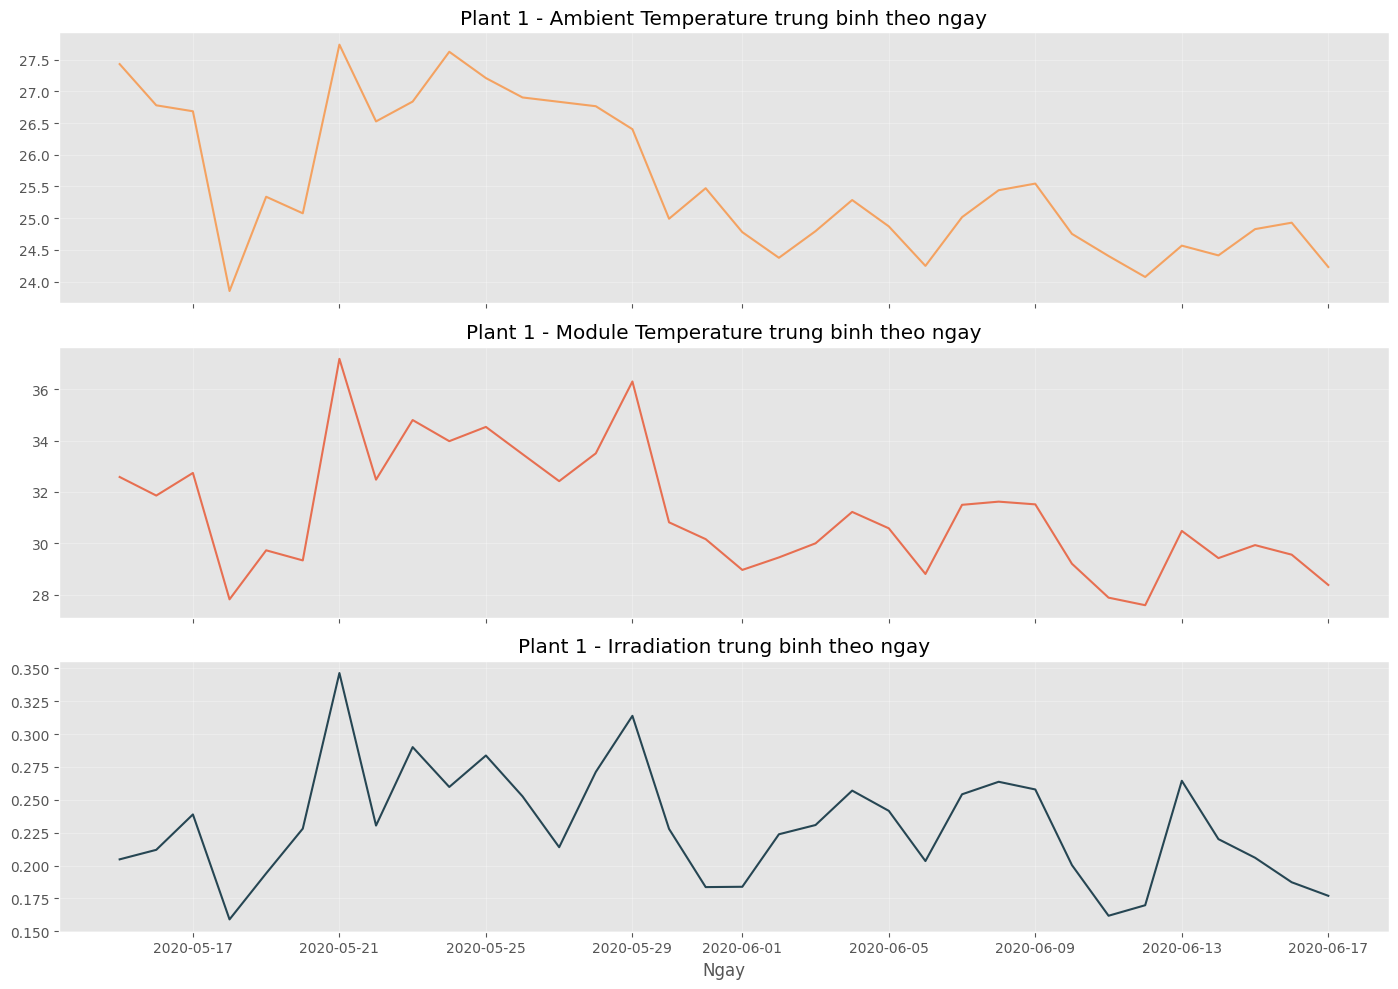

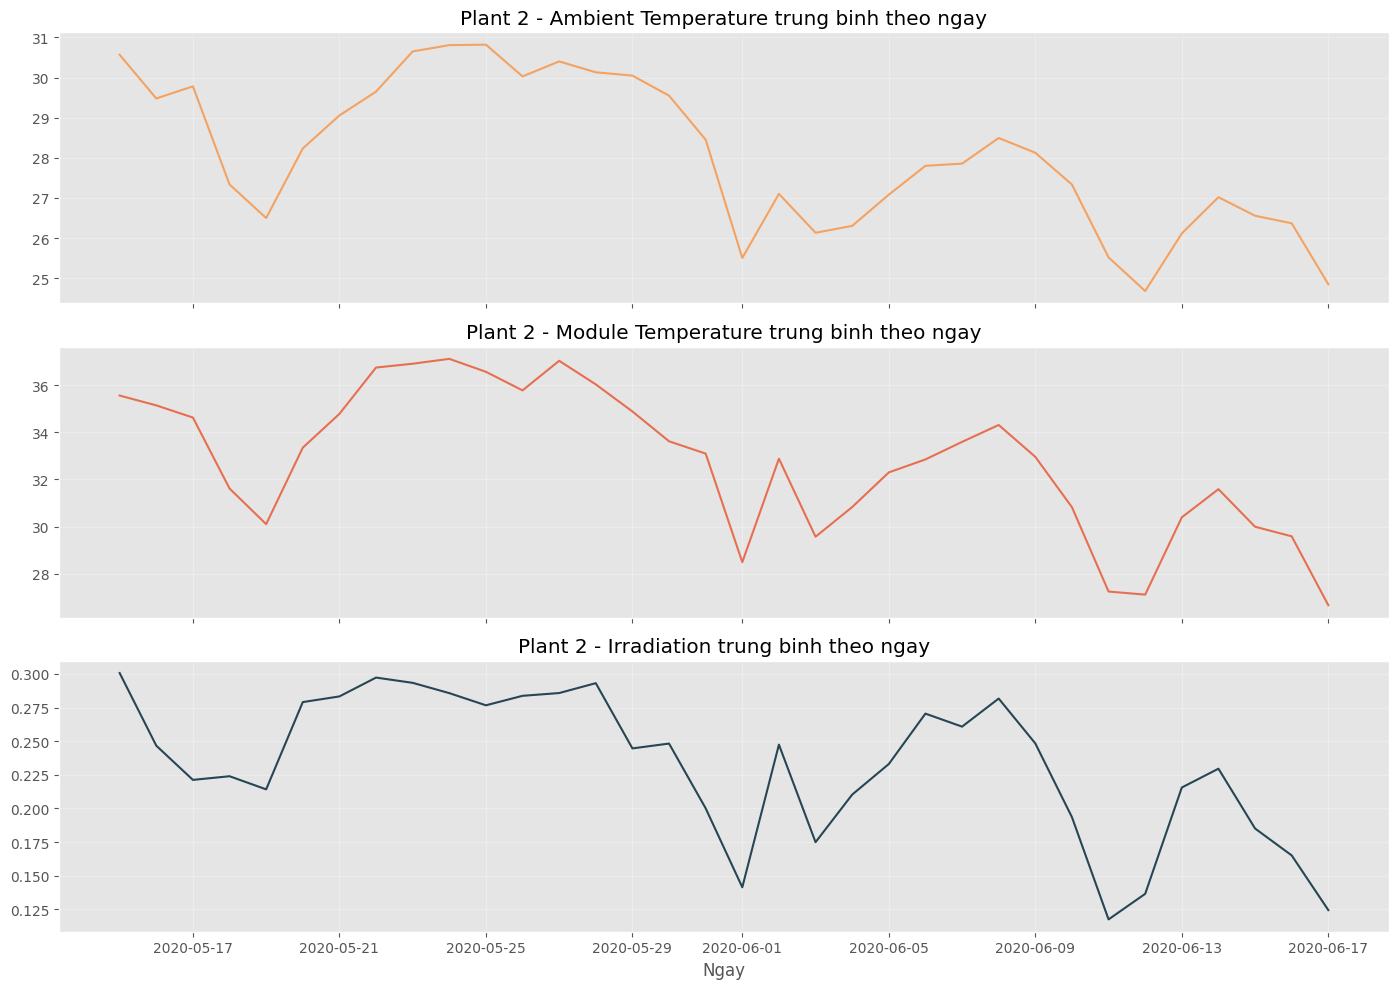

In [9]:
def plot_daily_weather(weather: pd.DataFrame, plant_no: int):
    daily = weather.copy()
    daily['DATE'] = daily['DATE_TIME'].dt.floor('D')
    daily = daily.groupby('DATE', as_index=False)[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].mean()

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(daily['DATE'], daily['AMBIENT_TEMPERATURE'], color='#f4a261')
    axes[0].set_title(f'Plant {plant_no} - Ambient Temperature trung binh theo ngay')

    axes[1].plot(daily['DATE'], daily['MODULE_TEMPERATURE'], color='#e76f51')
    axes[1].set_title(f'Plant {plant_no} - Module Temperature trung binh theo ngay')

    axes[2].plot(daily['DATE'], daily['IRRADIATION'], color='#264653')
    axes[2].set_title(f'Plant {plant_no} - Irradiation trung binh theo ngay')
    axes[2].set_xlabel('Ngay')

    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_daily_weather(plant_1_weather, 1)
plot_daily_weather(plant_2_weather, 2)

## 5. Tiền xử lý dữ liệu và ghép generation với weather

Đây là phần quan trọng nhất về mặt engineering. Ta không thể ghép trực tiếp bảng `generation` với bảng `weather` theo `SOURCE_KEY` vì hai bảng mô tả hai loại đối tượng khác nhau. Giải pháp đúng là:
1. Tổng hợp `generation` lên mức nhà máy theo từng mốc thời gian.
2. Ghép dữ liệu tổng hợp đó với thông tin thời tiết ở cùng thời điểm.

Ngoài ra, ta tạo thêm các đặc trưng thời gian như giờ, phút, ngày trong tuần và biến tuần hoàn `HOUR_SIN`, `HOUR_COS`. Những biến này giúp mô hình học được tính chu kỳ của dữ liệu theo ngày.

In [10]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['HOUR'] = df['DATE_TIME'].dt.hour
    df['MINUTE'] = df['DATE_TIME'].dt.minute
    df['DAY'] = df['DATE_TIME'].dt.day
    df['DAYOFWEEK'] = df['DATE_TIME'].dt.dayofweek
    df['MONTH'] = df['DATE_TIME'].dt.month
    df['DAYOFYEAR'] = df['DATE_TIME'].dt.dayofyear
    hour_float = df['HOUR'] + df['MINUTE'] / 60.0
    df['HOUR_SIN'] = np.sin(2 * np.pi * hour_float / 24)
    df['HOUR_COS'] = np.cos(2 * np.pi * hour_float / 24)
    df['IS_DAYLIGHT'] = ((df['HOUR'] >= 6) & (df['HOUR'] <= 18)).astype(int)
    return df

def aggregate_generation(gen: pd.DataFrame) -> pd.DataFrame:
    grouped = gen.groupby(['PLANT_ID', 'PLANT_NO', 'DATE_TIME'], as_index=False).agg(
        DC_POWER_TOTAL=('DC_POWER', 'sum'),
        AC_POWER_TOTAL=('AC_POWER', 'sum'),
        DAILY_YIELD_TOTAL=('DAILY_YIELD', 'sum'),
        TOTAL_YIELD_TOTAL=('TOTAL_YIELD', 'sum'),
        ACTIVE_SOURCE_COUNT=('SOURCE_KEY', 'nunique'),
        ZERO_AC_COUNT=('AC_POWER', lambda s: int((s == 0).sum()))
    )
    grouped['ZERO_AC_RATIO'] = grouped['ZERO_AC_COUNT'] / grouped['ACTIVE_SOURCE_COUNT']
    return grouped

def merge_generation_weather(gen: pd.DataFrame, weather: pd.DataFrame) -> pd.DataFrame:
    gen_agg = aggregate_generation(gen)
    weather = weather.rename(columns={'SOURCE_KEY': 'WEATHER_SENSOR_KEY'})
    merged = gen_agg.merge(weather, on=['PLANT_ID', 'PLANT_NO', 'DATE_TIME'], how='left')
    merged = add_time_features(merged)
    return merged

plant_1_merged = merge_generation_weather(plant_1_gen, plant_1_weather)
plant_2_merged = merge_generation_weather(plant_2_gen, plant_2_weather)
all_merged = pd.concat([plant_1_merged, plant_2_merged], ignore_index=True).sort_values('DATE_TIME').reset_index(drop=True)

print('Plant 1 merged:', plant_1_merged.shape)
print('Plant 2 merged:', plant_2_merged.shape)
print('All merged    :', all_merged.shape)

Plant 1 merged: (3158, 23)
Plant 2 merged: (3259, 23)
All merged    : (6417, 23)


Bảng tổng hợp dưới đây giúp kiểm tra kết quả merge. Chúng ta quan tâm đặc biệt đến cột `missing_weather_rows` vì nó cho biết có bao nhiêu thời điểm trong dữ liệu phát điện không tìm thấy bản ghi thời tiết tương ứng. Nếu số này lớn, cần xem lại logic ghép hoặc chất lượng dữ liệu thời gian.

In [11]:
pd.DataFrame({
    'plant_no': [1, 2],
    'merged_rows': [len(plant_1_merged), len(plant_2_merged)],
    'missing_weather_rows': [plant_1_merged['AMBIENT_TEMPERATURE'].isna().sum(), plant_2_merged['AMBIENT_TEMPERATURE'].isna().sum()],
    'target_mean_ac_power': [plant_1_merged['AC_POWER_TOTAL'].mean(), plant_2_merged['AC_POWER_TOTAL'].mean()]
})

,plant_no,merged_rows,missing_weather_rows,target_mean_ac_power
0,1,3158,1,"6,703.6281"
1,2,3259,0,"5,011.9749"


In [12]:
plant_1_merged.head()

,PLANT_ID,PLANT_NO,DATE_TIME,DC_POWER_TOTAL,AC_POWER_TOTAL,DAILY_YIELD_TOTAL,TOTAL_YIELD_TOTAL,ACTIVE_SOURCE_COUNT,ZERO_AC_COUNT,ZERO_AC_RATIO,WEATHER_SENSOR_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,MINUTE,DAY,DAYOFWEEK,MONTH,DAYOFYEAR,HOUR_SIN,HOUR_COS,IS_DAYLIGHT
0,4135001,1,2020-05-15 00:00:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,21,1.0000,HmiyD2TTLFNqkNe,25.1843,22.8575,0.0000,0,0,15,4,5,136,0.0000,1.0000,0
1,4135001,1,2020-05-15 00:15:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,21,1.0000,HmiyD2TTLFNqkNe,25.0846,22.7617,0.0000,0,15,15,4,5,136,0.0654,0.9979,0
2,4135001,1,2020-05-15 00:30:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,21,1.0000,HmiyD2TTLFNqkNe,24.9358,22.5923,0.0000,0,30,15,4,5,136,0.1305,0.9914,0
3,4135001,1,2020-05-15 00:45:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,21,1.0000,HmiyD2TTLFNqkNe,24.8461,22.3609,0.0000,0,45,15,4,5,136,0.1951,0.9808,0
4,4135001,1,2020-05-15 01:00:00,0.0000,0.0000,0.0000,"150,761,642.0000",22,22,1.0000,HmiyD2TTLFNqkNe,24.6215,22.1654,0.0000,1,0,15,4,5,136,0.2588,0.9659,0


## 6. Trực quan hóa tương quan sau khi merge

Sau khi dữ liệu đã được ghép về cùng một bảng, ta có thể xem mối tương quan giữa biến mục tiêu và các biến giải thích. Heatmap tương quan là công cụ trực quan giúp trả lời nhanh các câu hỏi:
- `IRRADIATION` có tương quan mạnh với công suất phát điện hay không.
- `AMBIENT_TEMPERATURE` và `MODULE_TEMPERATURE` có đi cùng với sản lượng hay không.
- Các biến thời gian hoặc biến vận hành có mối quan hệ đáng chú ý nào không.

Đây chưa phải là bằng chứng nhân quả, nhưng là tín hiệu tốt để xác định biến nào đáng chú ý trước khi huấn luyện mô hình.

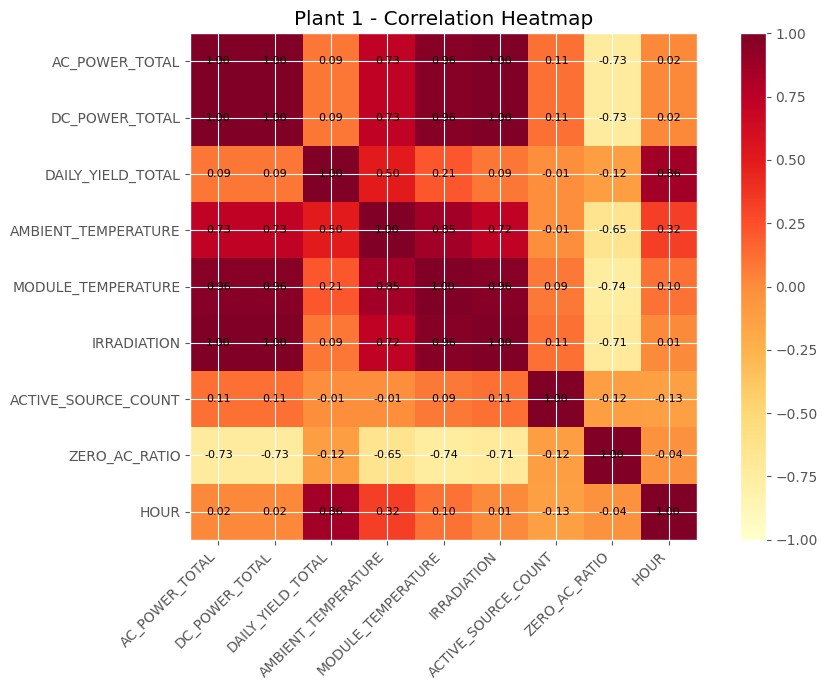

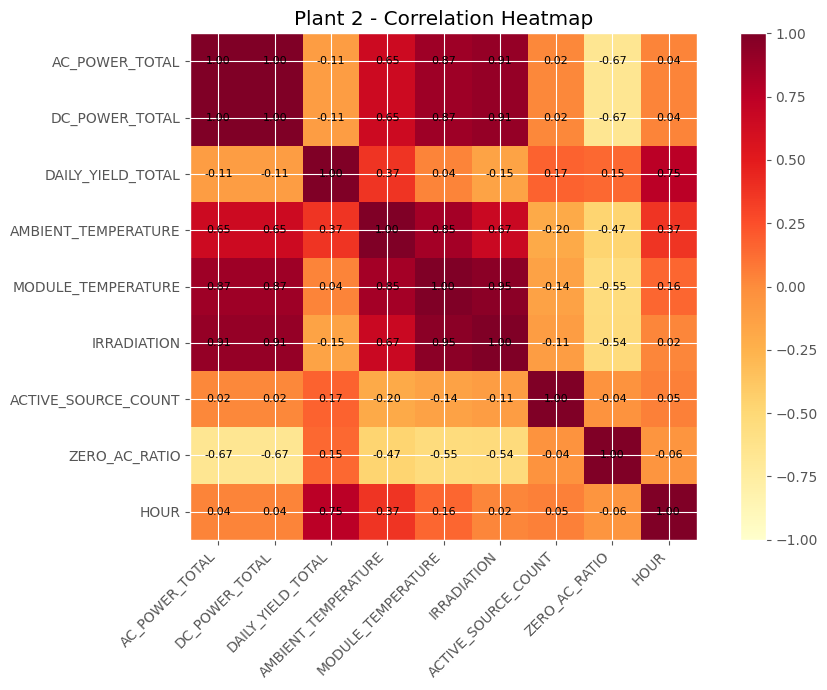

In [13]:
def plot_correlation_heatmap(df: pd.DataFrame, plant_no: int):
    numeric_cols = [
        'AC_POWER_TOTAL', 'DC_POWER_TOTAL', 'DAILY_YIELD_TOTAL',
        'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
        'ACTIVE_SOURCE_COUNT', 'ZERO_AC_RATIO', 'HOUR'
    ]
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(10, 7))
    plt.imshow(corr, cmap='YlOrRd', vmin=-1, vmax=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.colorbar()
    plt.title(f'Plant {plant_no} - Correlation Heatmap')
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(plant_1_merged.dropna(subset=['AMBIENT_TEMPERATURE']), 1)
plot_correlation_heatmap(plant_2_merged.dropna(subset=['AMBIENT_TEMPERATURE']), 2)

## 7. Chuẩn bị dữ liệu cho mô hình dự đoán sản lượng điện

Để dự đoán sản lượng điện, ta chọn biến mục tiêu là `AC_POWER_TOTAL` vì đây là công suất đầu ra ở mức nhà máy sau khi tổng hợp. Đây cũng là đại lượng dễ diễn giải và thường được quan tâm trong bài toán vận hành thực tế.

Ta chia dữ liệu theo thứ tự thời gian thay vì chia ngẫu nhiên. Lý do là trong bài toán time series hoặc dữ liệu có trật tự thời gian, chia ngẫu nhiên có thể làm rò rỉ thông tin từ tương lai vào quá khứ, dẫn tới đánh giá mô hình quá lạc quan.

In [14]:
model_df = all_merged.dropna(subset=['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']).copy()
model_df = model_df.sort_values('DATE_TIME').reset_index(drop=True)

feature_columns = [
    'PLANT_NO', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
    'HOUR', 'MINUTE', 'DAYOFWEEK', 'DAYOFYEAR', 'MONTH',
    'HOUR_SIN', 'HOUR_COS', 'IS_DAYLIGHT'
]
target_column = 'AC_POWER_TOTAL'

split_index = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

Train shape: (5132, 23)
Test shape : (1284, 23)


## 8. Huấn luyện mô hình Random Forest

Random Forest là một mô hình ensemble xây dựng nhiều cây quyết định và tổng hợp kết quả dự đoán của chúng. Mô hình này hoạt động tốt khi dữ liệu có quan hệ phi tuyến, ít đòi hỏi giả định chặt chẽ về phân phối dữ liệu và có thể xử lý tương tác phức tạp giữa các đặc trưng.

Trong cell dưới đây:
- Các biến số được đi qua bước điền khuyết bằng median.
- Biến phân loại `PLANT_NO` được mã hóa one-hot.
- Toàn bộ quá trình xử lý và mô hình được đóng gói trong một `Pipeline`.

Cách tổ chức này rất phù hợp với pipeline machine learning thực tế vì giảm rủi ro sai khác giữa bước train và bước predict.

In [15]:
numeric_features = [
    'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION',
    'HOUR', 'MINUTE', 'DAYOFWEEK', 'DAYOFYEAR', 'MONTH',
    'HOUR_SIN', 'HOUR_COS', 'IS_DAYLIGHT'
]
categorical_features = ['PLANT_NO']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1
    ))
])

model.fit(train_df[feature_columns], train_df[target_column])
test_df['PREDICTED_AC_POWER'] = model.predict(test_df[feature_columns])
test_df[['DATE_TIME', 'PLANT_NO', 'AC_POWER_TOTAL', 'PREDICTED_AC_POWER']].head()

,DATE_TIME,PLANT_NO,AC_POWER_TOTAL,PREDICTED_AC_POWER
5132,2020-06-11 07:15:00,2,"3,272.9043","3,132.1171"
5133,2020-06-11 07:15:00,1,"2,571.3661","2,414.4375"
5134,2020-06-11 07:30:00,2,"3,230.2205","3,125.3166"
5135,2020-06-11 07:30:00,1,"3,155.8571","2,953.5680"
5136,2020-06-11 07:45:00,2,"2,307.6671","2,166.1183"


## 9. Đánh giá mô hình

Sau khi mô hình dự đoán trên tập test, ta đánh giá bằng ba chỉ số:
- `MAE`: sai số tuyệt đối trung bình, dễ hiểu vì cùng đơn vị với công suất.
- `RMSE`: nhấn mạnh các sai số lớn, hữu ích khi muốn phạt mạnh các dự đoán lệch nhiều.
- `R2`: cho biết mô hình giải thích được bao nhiêu phần trăm biến thiên của dữ liệu.

Ta tính metric cho toàn bộ dữ liệu test và cho từng nhà máy riêng. Đây là cách kiểm tra quan trọng, vì một mô hình có thể tốt ở tổng thể nhưng lại lệch rõ ràng ở một nhà máy cụ thể.

In [16]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

metrics = []
metrics.append({'scope': 'overall', **regression_metrics(test_df['AC_POWER_TOTAL'], test_df['PREDICTED_AC_POWER'])})

for plant_no in sorted(test_df['PLANT_NO'].unique()):
    temp = test_df[test_df['PLANT_NO'] == plant_no]
    metrics.append({'scope': f'plant_{plant_no}', **regression_metrics(temp['AC_POWER_TOTAL'], temp['PREDICTED_AC_POWER'])})

metrics_df = pd.DataFrame(metrics)
metrics_df

,scope,MAE,RMSE,R2
0,overall,501.1533,"1,397.3392",0.9588
1,plant_1,257.7401,531.9027,0.9955
2,plant_2,743.8094,"1,901.8411",0.8818


## 10. Trực quan hóa kết quả dự đoán

Các chỉ số metric cho biết chất lượng mô hình dưới dạng số, nhưng biểu đồ đường giúp ta nhìn rõ hơn mức độ bám sát giữa giá trị thực tế và giá trị dự đoán. Nếu hai đường gần nhau ở phần lớn thời gian, mô hình đang nắm bắt được xu hướng phát điện khá tốt.

Khi đọc biểu đồ dự đoán, nên chú ý:
- Các đoạn đỉnh cao: mô hình có dự đoán hụt hoặc vượt mạnh không.
- Các đoạn công suất gần bằng 0: mô hình có nhận ra chu kỳ ban đêm hay không.
- Mức độ dao động giữa hai nhà máy có giống nhau không.

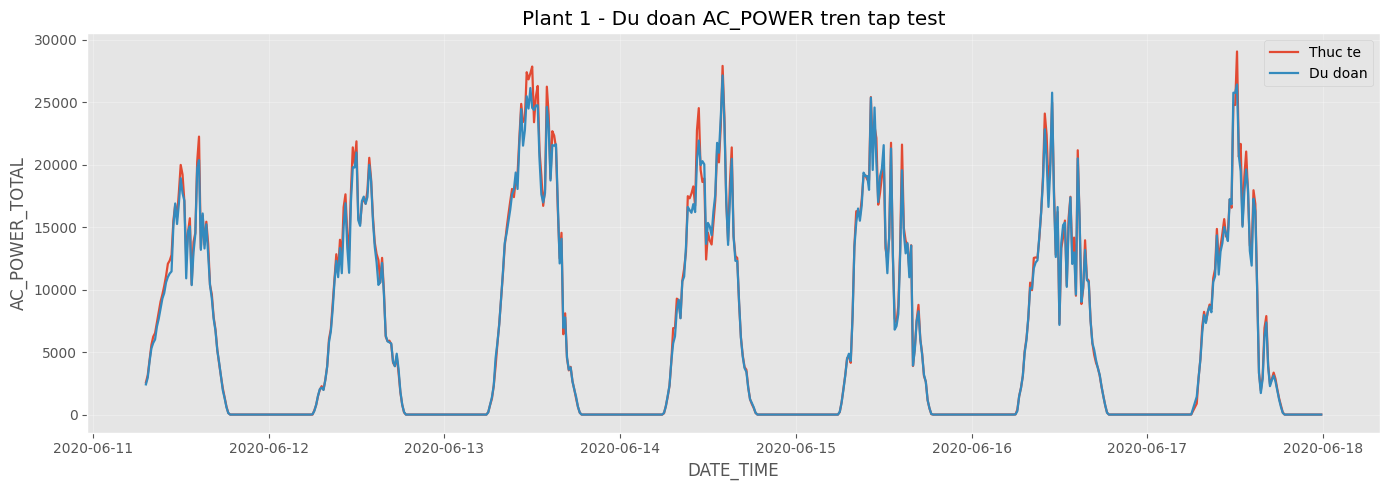

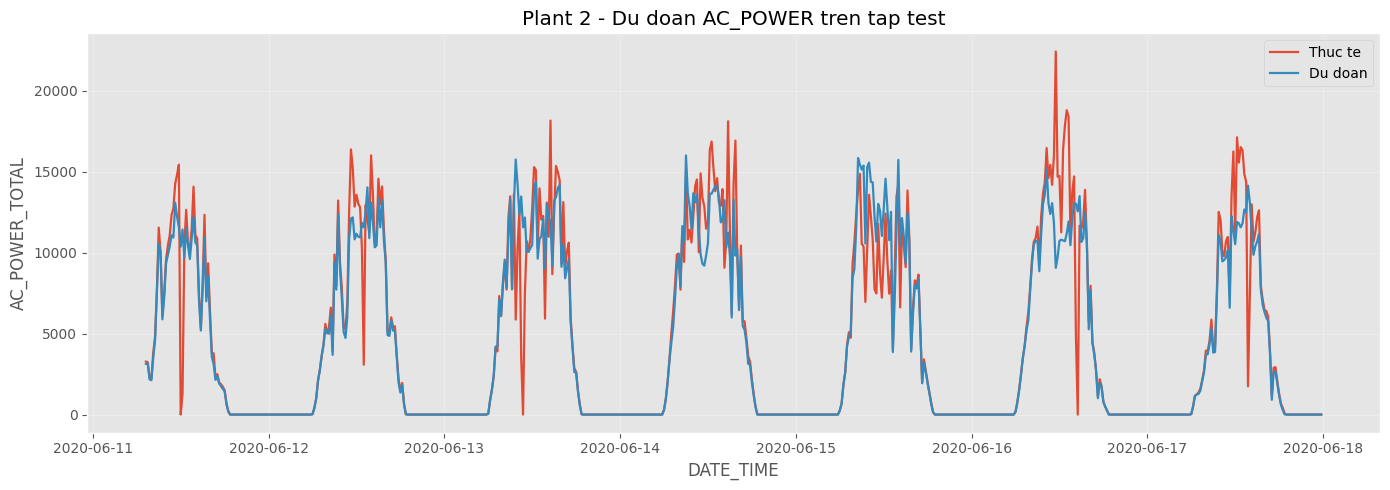

In [17]:
def plot_predictions(df: pd.DataFrame, plant_no: int):
    plt.figure(figsize=(14, 5))
    plt.plot(df['DATE_TIME'], df['AC_POWER_TOTAL'], label='Thuc te', linewidth=1.6)
    plt.plot(df['DATE_TIME'], df['PREDICTED_AC_POWER'], label='Du doan', linewidth=1.6)
    plt.title(f'Plant {plant_no} - Du doan AC_POWER tren tap test')
    plt.xlabel('DATE_TIME')
    plt.ylabel('AC_POWER_TOTAL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_predictions(test_df[test_df['PLANT_NO'] == 1], 1)
plot_predictions(test_df[test_df['PLANT_NO'] == 2], 2)

Phần tiếp theo kiểm tra `feature importance` của mô hình. Đây là một lợi thế thực tế của Random Forest, vì ngoài việc dự đoán tốt, mô hình còn cho ta biết biến nào đang đóng vai trò lớn nhất trong quyết định dự đoán.

Trong bài toán điện mặt trời, ta kỳ vọng `IRRADIATION` là biến quan trọng nhất. Nếu kết quả đúng như kỳ vọng này, đó là một dấu hiệu tốt cho thấy mô hình đang học theo quy luật hợp lý của hệ thống.

In [18]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out(feature_columns)
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.named_steps['regressor'].feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_df.head(12)

,feature,importance
2,num__IRRADIATION,0.9288
12,cat__PLANT_NO_2,0.0242
11,cat__PLANT_NO_1,0.0193
6,num__DAYOFYEAR,0.0112
5,num__DAYOFWEEK,0.0036
0,num__AMBIENT_TEMPERATURE,0.0035
1,num__MODULE_TEMPERATURE,0.0030
8,num__HOUR_SIN,0.0027
9,num__HOUR_COS,0.0018
7,num__MONTH,0.0008


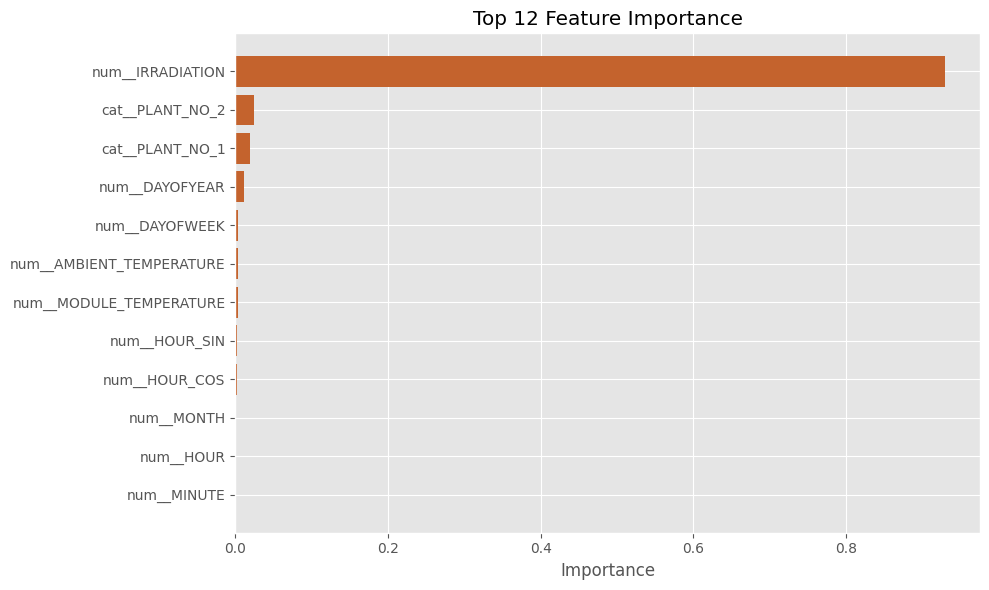

In [19]:
top_features = feature_importance_df.head(12).sort_values('importance')
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'], color='#c4632d')
plt.title('Top 12 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 11. Lưu dữ liệu đã xử lý và kết quả

Bước cuối cùng là lưu các bảng đã xử lý và kết quả dự đoán ra thư mục `outputs`. Việc này giúp tách rõ ba lớp dữ liệu:
- Dữ liệu nguồn ban đầu.
- Dữ liệu đã tiền xử lý và merge.
- Kết quả mô hình và các metric đánh giá.

Cách tổ chức này phù hợp với thực hành data engineering vì giúp tái sử dụng kết quả ở các bước sau mà không cần chạy lại toàn bộ pipeline.

In [20]:
plant_1_merged.to_csv(OUTPUT_DIR / 'plant_1_merged_from_notebook.csv', index=False)
plant_2_merged.to_csv(OUTPUT_DIR / 'plant_2_merged_from_notebook.csv', index=False)
all_merged.to_csv(OUTPUT_DIR / 'all_plants_merged_from_notebook.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'model_test_predictions_from_notebook.csv', index=False)
metrics_df.to_csv(OUTPUT_DIR / 'metrics_from_notebook.csv', index=False)
feature_importance_df.to_csv(OUTPUT_DIR / 'feature_importance_from_notebook.csv', index=False)

print('Da luu cac file ket qua vao:', OUTPUT_DIR)

Da luu cac file ket qua vao: z:\DOCUMENTS\KPDL\Prj_gr13\outputs


## 12. Kết luận gợi ý cho báo cáo

Từ notebook này, bạn có thể rút ra các ý chính cho phần kết luận báo cáo như sau:
- Dữ liệu của cả hai nhà máy tương đối sạch, ít thiếu giá trị và có thể ghép được theo thời gian.
- `IRRADIATION` là biến có ảnh hưởng mạnh nhất đến sản lượng điện.
- Việc tổng hợp dữ liệu từ mức inverter lên mức nhà máy là cần thiết để kết hợp với dữ liệu thời tiết.
- Mô hình Random Forest cho kết quả tốt trên bài toán dự đoán `AC_POWER_TOTAL`.
- Kết quả theo từng nhà máy có thể khác nhau, điều này gợi ý rằng điều kiện vận hành hoặc chất lượng dữ liệu giữa hai nhà máy không hoàn toàn giống nhau.

Nếu muốn mở rộng bài làm, bạn có thể thêm phần so sánh nhiều mô hình, phân tích lỗi dự đoán ở các ngày bất thường, hoặc xây dựng dashboard trực quan hóa tương tác.

In [21]:
all_merged

,PLANT_ID,PLANT_NO,DATE_TIME,DC_POWER_TOTAL,AC_POWER_TOTAL,DAILY_YIELD_TOTAL,TOTAL_YIELD_TOTAL,ACTIVE_SOURCE_COUNT,ZERO_AC_COUNT,ZERO_AC_RATIO,WEATHER_SENSOR_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,MINUTE,DAY,DAYOFWEEK,MONTH,DAYOFYEAR,HOUR_SIN,HOUR_COS,IS_DAYLIGHT
0,4135001,1,2020-05-15 00:00:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,21,1.0000,HmiyD2TTLFNqkNe,25.1843,22.8575,0.0000,0,0,15,4,5,136,0.0000,1.0000,0
1,4136001,2,2020-05-15 00:00:00,0.0000,0.0000,"48,899.9381","14,189,595,055.0000",22,22,1.0000,iq8k7ZNt4Mwm3w0,27.0048,25.0608,0.0000,0,0,15,4,5,136,0.0000,1.0000,0
2,4136001,2,2020-05-15 00:15:00,0.0000,0.0000,"28,401.0000","14,189,595,055.0000",22,22,1.0000,iq8k7ZNt4Mwm3w0,26.8808,24.4219,0.0000,0,15,15,4,5,136,0.0654,0.9979,0
3,4135001,1,2020-05-15 00:15:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,21,1.0000,HmiyD2TTLFNqkNe,25.0846,22.7617,0.0000,0,15,15,4,5,136,0.0654,0.9979,0
4,4135001,1,2020-05-15 00:30:00,0.0000,0.0000,0.0000,"143,581,676.0000",21,21,1.0000,HmiyD2TTLFNqkNe,24.9358,22.5923,0.0000,0,30,15,4,5,136,0.1305,0.9914,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6412,4136001,2,2020-06-17 23:15:00,0.0000,0.0000,"93,040.0000","14,194,078,746.0000",22,22,1.0000,iq8k7ZNt4Mwm3w0,23.3547,22.4922,0.0000,23,15,17,2,6,169,-0.1951,0.9808,0
6413,4135001,1,2020-06-17 23:30:00,0.0000,0.0000,"129,571.0000","156,142,755.0000",22,22,1.0000,HmiyD2TTLFNqkNe,21.9695,20.7350,0.0000,23,30,17,2,6,169,-0.1305,0.9914,0
6414,4136001,2,2020-06-17 23:30:00,0.0000,0.0000,"93,040.0000","14,194,078,746.0000",22,22,1.0000,iq8k7ZNt4Mwm3w0,23.2910,22.3739,0.0000,23,30,17,2,6,169,-0.1305,0.9914,0
6415,4135001,1,2020-06-17 23:45:00,0.0000,0.0000,"127,962.7679","156,142,755.0000",22,22,1.0000,HmiyD2TTLFNqkNe,21.9093,20.4280,0.0000,23,45,17,2,6,169,-0.0654,0.9979,0
